# SentimentScope: Sentiment Analysis using Transformers!
## Introduction <a name = "introduction"></a>

In this notebook, you will train a transformer model from scratch to perform sentiment analysis on the IMDB dataset. You are a Machine Learning Engineer at Cinescope, a growing entertainment company working to enhance its recommendation system. Your task is to fine-tune a transformer-based model for sentiment analysis using the IMDB dataset. By classifying reviews as positive or negative, you will help the company better understand user sentiment and deliver more personalized experiences.

By completing this project, you will demonstrate your competency in the following learning objectives:

- Load, explore, and prepare a text dataset for training a transformer model using PyTorch.
- Customize the architecture of the transformer model for a classification task.
- Train and test a transformer model on the IMDB dataset.

Now that you have an overview of what you will achieve in this project, let’s move on to the project outline.

---

### Project Outline

This notebook is organized into the following sections:


1. [Introduction](#introduction): Overview of the project, learning objectives, and understanding sentiment analysis.
2. [Load, Explore, and Prepare the Dataset](#load-explore-and-prepare-the-dataset): Load the IMDB dataset, explore it with visualizations, and split it into training and validation sets.
3. [Implement a DataLoader in PyTorch](#implement-a-dataloader-in-pytorch): Create the `IMDBDataset` class and use it with the PyTorch `DataLoader`, including tokenization.
4. [Customize the Transformer Architecture](#customize-the-transformer-architecture): Modify the transformer model for binary classification.
5. [Implement Accuracy Calculation Method](#implement-accuracy-calculation-method): Create a function to compute accuracy for monitoring performance.
6. [Train the Model](#train-the-model): Complete and execute the training loop for binary classification.
7. [Test the Model](#test-the-model): Evaluate the model on the test dataset and ensure it achieves over 75% accuracy.
8. [Conclusion](#conclusion): Summarize the project results and key takeaways.

Click on the section titles above to navigate directly to the corresponding part of the notebook!

---

Now that we've outlined the structure and objectives of this project, let's delve into the core concept: sentiment analysis.

### Understanding Sentiment Analysis

Sentiment analysis is a natural language processing (NLP) technique used to determine the sentiment expressed in a piece of text. This can range from identifying the polarity (positive, negative, or neutral) of a review to analyzing emotions and opinions.

In this project, sentiment analysis is explicitly framed as a **binary classification task**, where the goal is to determine whether a given movie review is *positive* or *negative*. This task is central to many real-world applications, including customer feedback analysis, social media monitoring, and recommendation systems. By developing a transformer-based model, you will classify IMDB movie reviews as positive or negative to tackle the challenge faced by your entertainment company CineScope by enhancing its recommendation system, enabling more accurate and personalized suggestions. 

Reviews labeled as positive will be marked as 1 in the dataset, while negative reviews will be labeled as 0.

For example, consider the following movie review:

> "The movie was a rollercoaster of emotions, and I loved every moment of it!"

This review is clearly positive as it expresses enjoyment and satisfaction with the movie, hence it will be labelled as *positive* or 1 in the dataset. In contrast:

> "The plot was predictable, and the acting was subpar. A waste of time."

This review conveys a negative sentiment, criticizing both the plot and acting, hence it will be labelled as *negative* or 0 in the dataset.

While transformers are often used for generation tasks, they can also be adapted for classification tasks with some modifications to their architecture. You might already be familiar with the tweaks that we will implement in this project.


---

### Data Description

The dataset used in this project is the [IMDB dataset](https://ai.stanford.edu/~amaas/data/sentiment/), provided in the `aclIMDB_v1.tar.gz` file. Upon extracting the file, you will find the following folder structure:

```
aclIMDB/
├── train/
│   ├── pos/    # Positive reviews for training
│   ├── neg/    # Negative reviews for training
│   ├── unsup/  # Unsupervised data (not used in this project)
├── test/
│   ├── pos/    # Positive reviews for testing
│   ├── neg/    # Negative reviews for testing
```

- **train/**: Contains labeled data for training the model. Reviews in the `pos/` folder should be labeled as positive (1), while reviews in the `neg/` folder should be labeled as negative (0).
- **test/**: Contains labeled data for evaluating the model. Similar to the training data, `pos/` and `neg/` contain positive and negative reviews, respectively.
- **unsup/**: Contains unlabeled reviews that are not used in this project.

Understanding the folder structure is crucial as it guides how we load and preprocess the data for the sentiment classification task.

---


## <a name="load-explore-and-prepare-the-dataset"></a>Load, Explore, and Prepare the Dataset

### 1. Load the Dataset
The dataset is already available in the environment as `aclIMDB_v1.tar.gz`. We will load it into Pandas DataFrames for easy exploration and preparation.


In [1]:
import json
import os
import random
import tarfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Permit individual unsupported MPS operations to fall back to CPU.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

%matplotlib inline


In [2]:
# Extract the bundled dataset once. Re-running the notebook is safe because an
# existing extraction is reused.
archive_path = Path("aclImdb_v1.tar.gz")
dataset_root = Path("aclImdb")

if not archive_path.exists():
    raise FileNotFoundError(f"Dataset archive not found: {archive_path.resolve()}")

if not dataset_root.exists():
    print(f"Extracting {archive_path.name}...")
    with tarfile.open(archive_path, "r:gz") as archive:
        archive.extractall(path=".", filter="data")
    print("Dataset extracted.")
else:
    print(f"Using existing dataset directory: {dataset_root.resolve()}")


Using existing dataset directory: /Users/cyborg/Documents/MASTER AI/udacity_nd089/cd13905-transformers-project-starter/starter/aclImdb


You have successfully extracted the folder. Go back to your workspace and explore the folder structure and find the relative paths for each of the following:
- Training positive reviews
- Training negative reviews
- Testing positive reviews
- Testing negative reviews

Assign the paths of these folders relative to the starter file in the variables below.


In [3]:
# Define paths to the four labelled dataset folders.
train_pos_path = dataset_root / "train" / "pos"
train_neg_path = dataset_root / "train" / "neg"
test_pos_path = dataset_root / "test" / "pos"
test_neg_path = dataset_root / "test" / "neg"

for path in [train_pos_path, train_neg_path, test_pos_path, test_neg_path]:
    if not path.is_dir():
        raise FileNotFoundError(f"Expected dataset directory not found: {path}")
    print(path, "->", len(list(path.glob("*.txt"))), "reviews")


aclImdb/train/pos -> 12500 reviews
aclImdb/train/neg -> 12500 reviews
aclImdb/test/pos -> 12500 reviews
aclImdb/test/neg -> 12500 reviews


Now, you will implement the `load_dataset()` function, which reads all text files in a specified folder and returns their content as a list of strings. This function is essential for loading and preprocessing the dataset in subsequent steps.

To implement this function:

1. **Use the `os` module**: Leverage Python's `os` module to list all files in the folder.
2. **Handle file paths**: Use `os.path.join()` to construct full paths for files, ensuring compatibility across operating systems.
3. **Read file content**: Open each file in read mode (`'r'`) using UTF-8 encoding to handle text properly.
4. **Aggregate results**: Append the content of each file to a list and return it.

### Key Points to Consider:
- Ensure that the function only processes text files (you may use file extensions for filtering if needed).
- Refer to the [os.listdir documentation](https://docs.python.org/3/library/os.html#os.listdir) for listing files in a directory.


In [4]:
def load_dataset(folder):
    """
    Read all UTF-8 text files in a folder and return their contents.

    Sorting file names makes the dataset order reproducible across platforms.
    """
    reviews = []
    folder = Path(folder)

    for file_path in sorted(folder.iterdir()):
        if file_path.is_file() and file_path.suffix == ".txt":
            with file_path.open("r", encoding="utf-8") as file:
                reviews.append(file.read())

    return reviews


Use the function now to load the training and testing data:

In [5]:
# Load training and testing data.
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

print(
    f"Loaded train: {len(train_pos):,} positive, {len(train_neg):,} negative | "
    f"test: {len(test_pos):,} positive, {len(test_neg):,} negative"
)


Loaded train: 12,500 positive, 12,500 negative | test: 12,500 positive, 12,500 negative


We can convert the data into pandas dataframes to make handling the datasets easier.

In [6]:
# Create DataFrames
train_df = pd.DataFrame({
    'review': train_pos + train_neg,
    'label': [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    'review': test_pos + test_neg,
    'label': [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())

                                              review  label
0  Bromwell High is a cartoon comedy. It ran at t...      1
1  Homelessness (or Houselessness as George Carli...      1
2  Brilliant over-acting by Lesley Ann Warren. Be...      1
3  This is easily the most underrated film inn th...      1
4  This is not the typical Mel Brooks film. It wa...      1


You can ensure that your datasets have loaded correctly by running the following code cell. No output means success!

In [7]:
# Assert that both datasets have the expected number of rows
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."

# Assert that both datasets have exactly two columns
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."


### 2. Explore the Dataset
Exploration helps us understand the dataset's structure and distribution.

Here are some suggestions for exploration and visualizations:
- **Dataset Overview**: Use `DataFrame.info()` and `DataFrame.describe()` to understand the dataset structure and basic statistics.
- **Label Distribution**: Create bar charts to visualize the number of positive and negative reviews.
- **Review Length Analysis**: Compute and plot the distribution of review lengths (e.g., number of characters or words).
- **Sample Reviews**: Print a few positive and negative reviews to understand the text content.

Write code to explore the dataset in this section.

In [8]:
# Dataset structure and descriptive statistics.
print("Training DataFrame information:")
train_df.info()

print("\nTraining label statistics:")
display(train_df["label"].describe().to_frame().T)


Training DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 390.8 KB

Training label statistics:


,count,mean,std,min,25%,50%,75%,max
label,25000.0,0.5,0.50001,0.0,0.0,0.5,1.0,1.0


In [9]:
# Calculate review-length metrics without modifying the two-column DataFrame.
train_word_counts = train_df["review"].str.split().str.len()
train_character_counts = train_df["review"].str.len()

length_statistics = pd.DataFrame({
    "word_count": train_word_counts,
    "character_count": train_character_counts,
}).describe()

print("Review-length descriptive statistics:")
display(length_statistics)


Review-length descriptive statistics:


,word_count,character_count
count,25000.000000,25000.00000
mean,233.787200,1325.06964
std,173.733032,1003.13367
min,10.000000,52.00000
25%,127.000000,702.00000
50%,174.000000,979.00000
75%,284.000000,1614.00000
max,2470.000000,13704.00000


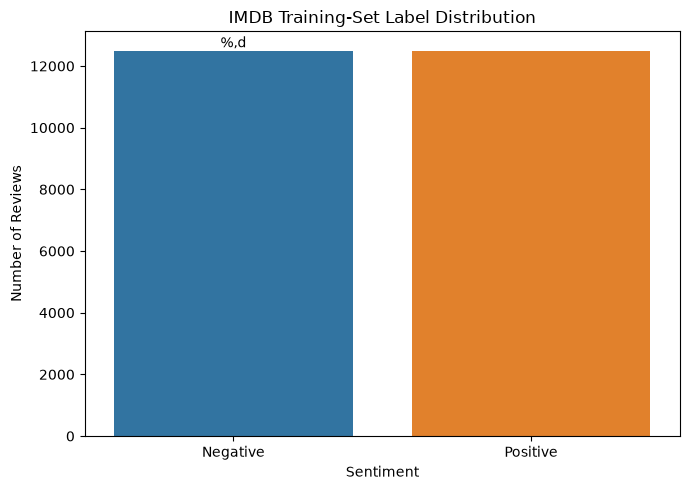

In [10]:
# Visualization 1: class balance.
label_counts = (
    train_df["label"]
    .map({0: "Negative", 1: "Positive"})
    .value_counts()
    .reindex(["Negative", "Positive"])
)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, legend=False)
ax.bar_label(ax.containers[0], fmt="%,d")
plt.title("IMDB Training-Set Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


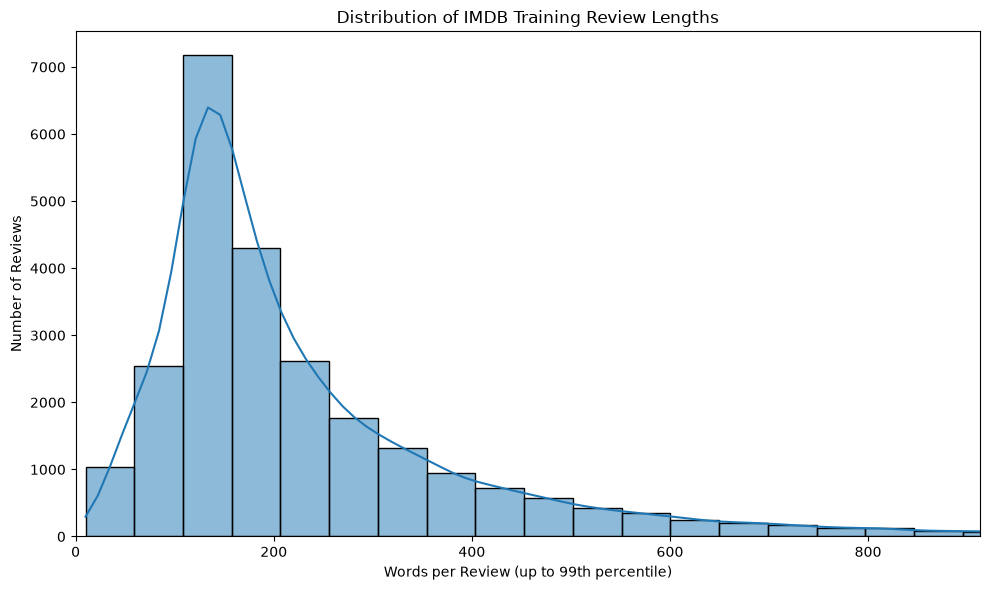

Example positive review:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a s ...

Example negative review:
Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The cryptic dialogue would make Shakespeare seem

In [11]:
# Visualization 2: review-length distribution. The 99th-percentile limit keeps
# a small number of extremely long reviews from compressing the main pattern.
word_count_limit = int(train_word_counts.quantile(0.99))

plt.figure(figsize=(10, 6))
sns.histplot(train_word_counts, bins=50, kde=True)
plt.xlim(0, word_count_limit)
plt.title("Distribution of IMDB Training Review Lengths")
plt.xlabel("Words per Review (up to 99th percentile)")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

print("Example positive review:")
print(train_df.loc[train_df["label"] == 1, "review"].iloc[0][:500], "...")
print("\nExample negative review:")
print(train_df.loc[train_df["label"] == 0, "review"].iloc[0][:500], "...")


### 3. Prepare the Dataset
We will split the training data further into training and validation subsets. The way we constructed the dataset, reviews with positive and negative labels are segregated. To ensure that the validation dataset works well, we first need to shuffle the dataset.


In [12]:
# Shuffle deterministically, then split 90%/10% into training and validation.
train_size = int(0.9 * len(train_df))
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_data = shuffled_df.iloc[:train_size].reset_index(drop=True)
val_data = shuffled_df.iloc[train_size:].reset_index(drop=True)

print(f"Training rows: {len(train_data):,}")
print(f"Validation rows: {len(val_data):,}")
print("Training positive rate:", f"{train_data['label'].mean():.3f}")
print("Validation positive rate:", f"{val_data['label'].mean():.3f}")


Training rows: 22,500
Validation rows: 2,500
Training positive rate: 0.500
Validation positive rate: 0.499


### 4. Testing the Tokenizer

#### Subword Tokenization
In earlier tasks, you might have encountered character-level tokenization, where each character in the text is treated as a token. While this is straightforward, it is less efficient and may result in larger input sizes, impacting the performance of transformer models.

To address this, we will use Hugging Face's `AutoTokenizer`, a robust and efficient class designed for tokenizing text based on pretrained models. Specifically, we will utilize the `bert-base-uncased` tokenizer, which applies **subword tokenization**. Subword tokenization involves two steps:

1. **Subword Splitting**: Words are split into smaller components (subwords) based on a predefined vocabulary. For example:
   - Input: "unhappiness"
   - Subword Splits: `['un', 'happiness']`

2. **Token Conversion**: Each subword is then converted into a numerical token ID. For example:
   - Subword Splits: `['un', 'happiness']`
   - Token IDs: `[1011, 24123]` (values are illustrative and depend on the tokenizer vocabulary).

#### About the `bert-base-uncased` Tokenizer
The `bert-base-uncased` tokenizer, developed by Google researchers, is part of the BERT model family. This tokenizer is associated with the `bert-base-uncased` model, which has been widely used for tasks such as sentiment analysis, question answering, and text classification. The tokenizer ensures all text is converted to lowercase and accents are removed, reducing vocabulary size and improving generalization. Example:

- Input: "I Love Transformers."
- Subword Splits: `['i', 'love', 'trans', '##formers', '.']`

You can learn more about the tokenizer and model on [Hugging Face's bert-base-uncased page](https://huggingface.co/bert-base-uncased).

#### Using the `AutoTokenizer` Class
The `AutoTokenizer` class in the Hugging Face Transformers library provides a seamless way to load tokenizers for various pretrained models. It automatically selects the correct tokenizer configuration based on the model name.


In [13]:
from transformers import AutoTokenizer
from huggingface_hub.utils import logging as hf_logging

# The tokenizer is public; suppress the optional authentication notice.
hf_logging.set_verbosity_error()
TOKENIZER_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME, use_fast=True)
print(f"Tokenizer: {tokenizer.__class__.__name__}, vocabulary: {tokenizer.vocab_size:,}")


/Users/cyborg/Documents/MASTER AI/udacity_nd089/cd13905-transformers-project-starter/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tokenizer: BertTokenizer, vocabulary: 30,522


This initializes a tokenizer tailored for the `bert-base-uncased` model. You can refer to the [Hugging Face AutoTokenizer documentation](https://huggingface.co/docs/transformers/main_classes/tokenizer) for more details. You can find the definition of the `from_pretrained()` method [here](https://huggingface.co/docs/transformers/v4.48.0/en/model_doc/auto#transformers.AutoTokenizer.from_pretrained).

Instead of tokenizing the entire dataset, we will test the tokenizer on a few sample reviews directly from the dataset:


In [14]:
# Take sample inputs from the dataset
sample_texts = train_data['review'].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(sample_texts, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

In [15]:
print(tokenized_samples)

{'input_ids': tensor([[  101,  2348,  1996,  3185,  2003,  4415,  6052,  1010,  9501,  2064,
          2145,  4089,  6709,  2007,  1996, 24525,  1997,  5292, 21112,  2015,
         18396,  1999,  2023, 27768,  1998,  2200,  6057,  2104, 16168,  6925,
          1012, 18396,  9590,  2114,  4895, 18824,  2135, 10238,  1999,  2093,
          2367,  5535,  1024,  1996,  2962,  2287,  1010,  1996,  3142,  2287,
          1010,  1998,  1996,  5549,  2078,  2287,  1010,  2652,  2471,  1996,
          2168,  2839,  2007,  2074,  1037,  2689,  1997, 17363,  2000,  2393,
          2149,  6709,  1996,  2367,  1000,  5535,  1000,  1012,  1999,  2023,
          3185,  2057,  2156,  2028,  1997,  1996,  5700, 21699, 20818,  1997,
          1996,  1000,  5430,  2386,  1000, 12991, 13874,  1010,  2040,  5222,
          2010,  2293,  2025,  2011,  7472,  2021,  2011, 26128,  2486,  1010,
          2004,  2092,  2004,  1037,  6057,  9792,  2006,  3142,  5580,  2401,
         29469,  2389,  4337,  1010,  

Explanation of parameters:
 - `truncation=True`: Truncates text longer than the specified max_length.
 - `padding=True`: Pads shorter sequences to match max_length.
 - `max_length=128`: Specifies the maximum length of the sequences.
 - `return_tensors="pt"`: Returns PyTorch tensors as the output format.
 
For more details about truncation and padding, refer to the [Hugging Face Padding and Truncation Documentation](https://huggingface.co/docs/transformers/pad_truncation). This step ensures that the tokenizer works as expected and provides insight into its behavior. Next, we will use the tokenizer within the class definition to process the dataset.

---


# Implement a DataLoader in PyTorch<a id="implement-a-dataloader-in-pytorch"></a>


In this section, you will implement a custom dataset class and use it to create a DataLoader in PyTorch for feeding data into the model during training. PyTorch simplifies this process by providing the `Dataset` and `DataLoader` classes, which handle batching, shuffling, and preprocessing, allowing you to focus on the model architecture and training.

To start, we will create a custom dataset class for the IMDB dataset, which will process and return tokenized inputs along with their corresponding labels. This class will use a tokenizer to preprocess the raw text data.

### 1. Define a Custom Dataset Class

The custom dataset class will inherit from `torch.utils.data.Dataset` and include the following features:

1. **Initialization (`__init__`)**:
   - Accepts raw text and label data, along with a tokenizer and a maximum sequence length.
   - The tokenizer is used to preprocess the text data into tokenized inputs.
   - The maximum sequence length ensures that all tokenized inputs are of uniform length.

2. **Length (`__len__`)**:
   - Returns the total number of data samples in the dataset.

3. **Item Retrieval (`__getitem__`)**:
   - Retrieves a single data point by index.
   - Preprocesses the text using the tokenizer to create tokenized input IDs.
   - Returns the tokenized input IDs and the corresponding label for the given index.

You can refer to [this](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) tutorial on the Pytorch website for more details.


In [16]:
import torch
from torch.utils.data import Dataset

MAX_LENGTH = 128
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Using device:", device)


PyTorch version: 2.13.0
Using device: mps


**NOTE ABOUT GPU USAGE**

The workspace provides you with access to a GPU which is necessary for training a transformer model due to the efficiency provided by GPUs on the large amount of computations that are required. To ensure judicious usage of limited resources, please usage the GPU only when you are training the model. 

---
We will keep the maximum length of input to 128 tokens.

In [17]:
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    """Tokenize IMDB reviews lazily and return input IDs with integer labels."""

    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self._token_cache = {}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        idx = int(idx)
        label = int(self.data.loc[idx, "label"])

        if idx not in self._token_cache:
            text = self.data.loc[idx, "review"]
            encoded = self.tokenizer(
                text,
                truncation=True,
                padding="max_length",
                max_length=self.max_length,
                return_tensors="pt",
            )
            self._token_cache[idx] = encoded["input_ids"].squeeze(0)

        return self._token_cache[idx], label


### 2. Initialize the Dataset

Once the `IMDBDataset` class is defined, we can initialize it directly with the training and validation DataFrames.

In [18]:
# Initialize the datasets
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

### 3. Create a DataLoader

The `DataLoader` class in PyTorch helps manage batches of data during training. We will use it to create training and validation data loaders.

In [19]:
from torch.utils.data import DataLoader

# Batch size 32 fits the 4.7M-parameter model on the 16 GB M4 Mac.
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

print(
    f"Batches -> train: {len(train_loader)}, "
    f"validation: {len(val_loader)}, test: {len(test_loader)}"
)


Batches -> train: 704, validation: 79, test: 782



You may have seen the use of `RandomShuffler` along with `DataLoader`. That approach is used when you want to train a model over a dataset randomly for a specified number of steps. In this model, we want to use the epoch approach.

An **epoch** is one complete pass through the entire dataset. When using the `DataLoader` in this setup, it ensures that every data point in the dataset is used exactly once during a single epoch. This approach is helpful for training models in a structured manner, ensuring that the model sees all the training examples and learns from them in each epoch before moving to the next one.

By setting `shuffle=True` for the `train_loader`, the data points are randomly shuffled at the start of each epoch, improving the generalization of the model. You will see this in action later in the code for training the model.

---
Given below are some assert statements to check your custom dataset and data loader definitions.

In [20]:
assert len(train_dataset) == 22500, "Train dataset length mismatch!"
assert len(val_dataset) == 2500, "Validation dataset length mismatch!"
assert len(test_dataset) == 25000, "Test dataset length mismatch!"

import numpy as np

# Check the first item in the train dataset
input_ids, label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(label, (int, np.integer)), "Label should be an integer or int-like!"

# Ensure the input IDs tensor has the correct shape
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"

## <a id="customize-the-transformer-architecture"></a>Customize the Transformer Architecture

In this section, you will customize the transformer architecture to suit the task of binary classification. You may have used a similar architecture in the past for generation tasks. But you will need to make a few tweaks specifically in the `DemoGPT` class to adapt it for the binary classification.

### 1. Config Dictionary
Your config dictionary bundles all hyperparameters and model settings in one place. Below is the config that we will use in our model:

In [21]:
config = {
    "vocabulary_size": tokenizer.vocab_size,
    "num_classes": 2,
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,
    "dropout_rate": 0.1,
    "use_bias": True,
    "pad_token_id": tokenizer.pad_token_id,
}


Key Config Parameters:
- `vocabulary_size`: The total number of tokens in your vocabulary.
- `num_classes`: The number of classes for the classification head (2 = binary).
- `d_embed`: Dimensionality of embeddings (and hidden layers).
- `context_size`: Maximum sequence length for each input.
- `layers_num`: Number of stacked transformer blocks.
- `heads_num`: Number of attention heads in multi-head attention.
- `head_size`: Dimension of each attention head (must satisfy heads_num * head_size = d_embed).
- `dropout_rate`: Probability of dropping units during training to reduce overfitting.
- `use_bias`: Whether linear layers should have bias terms.



### 2. Class Definitions

Below are the class definitions you will work with. These classes form the core components of the transformer model. You may have seen these before, with the exception of the `DemoGPT` class which will need to be customized.


#### AttentionHead

In [22]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        # Casual Mask
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
            float('-inf')
        )
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

Here we use a dummy input aligned with our config:

- Batch size = `BATCH_SIZE` (32)
- Sequence length = `config["context_size"]` (128)
- Embedding dimension = `config["d_embed"]` (128)


In [23]:
# Instantiate the AttentionHead
attention_head = AttentionHead(config).to(device)

# Create a dummy input of shape (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
attention_output = attention_head(dummy_input)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 128, 32])


Expected shape:

>`(B,T,head_size)=(32,128,32)`

#### MultiHeadAttention


In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                   # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [25]:
# Instantiate MultiHeadAttention
multi_head_attention = MultiHeadAttention(config).to(device)

# Same dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
mha_output = multi_head_attention(dummy_input)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 128, 128])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### FeedForward


In [26]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [27]:
# Instantiate FeedForward
feed_forward = FeedForward(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 128, 128])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### Block


In [28]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [29]:
# Instantiate a single Block
block = Block(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
block_output = block(dummy_input)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 128, 128])


Expected shape:

>`(B,T,d_embed)=(32,128,128)`

#### DemoGPT
Below is the starter code for the `DemoGPT` class, which implements the core of a transformer model tailored for a binary classification task. This implementation builds on the foundation of a transformer architecture and includes the necessary modifications to adapt it for classification. 

### Key Changes for Binary Classification

To adapt the transformer for classification, the following changes are required:

1. **Add a Classification-Specific Output Layer**:
   - The model needs a linear layer to map the final pooled embeddings to the number of classes. 
   - The classification head is implemented using [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) with:
     - `in_features` set to `d_embed` (the embedding dimension).
     - `out_features` set to `num_classes` (the number of classes, 2 for binary classification).
     - `bias` set to `False` (optional; bias can be excluded to slightly simplify computations).


2. **Implement a Pooling Mechanism**:

   - Transformers output embeddings for each token in the input sequence. For classification, these token-level embeddings need to be condensed into a single vector.

   - A **mean pooling operation** is applied using [`torch.mean`](https://pytorch.org/docs/stable/generated/torch.mean.html) across the time dimension (`dim=1`) to aggregate token-level embeddings into a single representation vector.

In [30]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.pad_token_id = config["pad_token_id"]
        self.token_embedding_layer = nn.Embedding(
            config["vocabulary_size"], config["d_embed"]
        )
        self.positional_embedding_layer = nn.Embedding(
            config["context_size"], config["d_embed"]
        )
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)
        self.layer_norm = nn.LayerNorm(config["d_embed"])

        # Classification head: pooled embedding -> positive/negative logits.
        self.output_layer = nn.Linear(
            config["d_embed"], config["num_classes"], bias=False
        )

    def forward(self, token_ids):
        batch_size, tokens_num = token_ids.shape

        x = self.token_embedding_layer(token_ids)
        positions = torch.arange(tokens_num, device=token_ids.device)
        pos_embed = self.positional_embedding_layer(positions)
        x = x + pos_embed.unsqueeze(0)

        x = self.layers(x)
        x = self.layer_norm(x)

        # Mask-aware mean pooling prevents padding tokens from dominating short
        # reviews while still applying mean pooling across the time dimension.
        token_mask = (token_ids != self.pad_token_id).unsqueeze(-1)
        pooled = (x * token_mask).sum(dim=1)
        pooled = pooled / token_mask.sum(dim=1).clamp(min=1)

        logits = self.output_layer(pooled)
        return logits


In [31]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Suppose we have a batch of size 32, each with a sequence length of 128
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"], 
    (BATCH_SIZE, config["context_size"])
).to(device)

# Forward pass
logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])  # Print first two examples' logits

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 

tensor([[-0.1121,  0.0161],
        [-0.1241, -0.0633]], device='mps:0', grad_fn=<SliceBackward0>)


Expected shape:

> `(B,num_classes)=(32,2)`


In [32]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

## Implement Accuracy Calculation Method <a name="implement-accuracy-calculation-method"></a>

In this section, you will learn how to calculate the validation accuracy for the transformer model on the IMDB dataset. Validation accuracy provides a performance metric that helps assess how well the model generalizes to unseen data during training.

### 1. Overview
The function to calculate validation accuracy will:

- Evaluate the model on the validation dataset.
- Generate predictions for each batch.
- Compare predictions with the true labels.
- Compute the percentage of correctly classified examples.

### 2.  Key Points
- **Evaluation Mode**: Calling `model.eval()` ensures that dropout and other training-specific layers are disabled during evaluation.
- **No Gradients**: The `torch.no_grad()` context disables gradient computation, reducing memory usage and speeding up validation.
- **Predictions**: `torch.argmax(logits, dim=1)` retrieves the index of the highest logit for each sample, which corresponds to the predicted class label.
- **Accuracy Calculation**: The function computes the fraction of correct predictions out of the total number of samples, then multiplies by 100 to express it as a percentage.

After calculating the validation accuracy, incorporate this function into your training loop. Typically, you would call calculate_accuracy at the end of each epoch or after a specific number of training steps. Monitoring validation accuracy over time helps you track performance gains and identify potential overfitting or underfitting issues.

In [33]:
def calculate_accuracy(model, data_loader, device):
    """Return classification accuracy as a percentage."""
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)
            logits = model(input_ids)
            predictions = torch.argmax(logits, dim=1)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    return (total_correct / total_samples) * 100


In [34]:
# Confirm the untrained baseline is near random chance.
torch.manual_seed(RANDOM_SEED)
model = DemoGPT(config).to(device)


In [35]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 49.84%


As you can see, the validation accuracy is close to 50%. This is expected as the model's parameters have been initialized randomly. 

## Train the Model <a name="train-the-model"></a>

In this section, we will define the training loop for the transformer-based model designed for sentiment analysis. The training loop is crucial for optimizing the model's weights and biases to minimize the loss function and improve classification performance.

### Training Loop

The training loop will involve the following steps:

1. **Iterate through epochs**: Repeat the training process for a predefined number of epochs.
2. **Load batches of data**: Use the `DataLoader` to retrieve batches of input IDs and labels.
3. **Forward pass**: Compute the logits by passing the input IDs through the model.
4. **Compute loss**: Use cross-entropy loss as the criterion.
5. **Backward pass and optimization**: Backpropagate the loss and update the model parameters using the optimizer.
6. **Validation**: Calculate the validation accuracy after each epoch.


In [36]:
import torch.optim as optim

EPOCHS = 3
LEARNING_RATE = 3e-4
CHECKPOINT_PATH = Path("sentimentscope_model.pt")

torch.manual_seed(RANDOM_SEED)
model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

training_history = []
best_val_accuracy = 0.0
training_started = time.perf_counter()

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_started = time.perf_counter()

    for step, (input_ids, labels) in enumerate(train_loader):
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        logits = model(input_ids)
        loss = criterion(logits, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if (step + 1) % 100 == 0:
            print(
                f"Epoch [{epoch + 1}/{EPOCHS}], "
                f"Step [{step + 1}/{len(train_loader)}], "
                f"Mean loss: {epoch_loss / (step + 1):.4f}"
            )

    val_accuracy = calculate_accuracy(model, val_loader, device)
    mean_loss = epoch_loss / len(train_loader)
    epoch_minutes = (time.perf_counter() - epoch_started) / 60

    training_history.append({
        "epoch": epoch + 1,
        "training_loss": mean_loss,
        "validation_accuracy": val_accuracy,
        "minutes": epoch_minutes,
    })

    print(
        f"Epoch {epoch + 1}: loss={mean_loss:.4f}, "
        f"validation accuracy={val_accuracy:.2f}%, "
        f"time={epoch_minutes:.1f} minutes"
    )

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        cpu_state = {
            key: value.detach().cpu()
            for key, value in model.state_dict().items()
        }
        torch.save({
            "model_state_dict": cpu_state,
            "config": config,
            "tokenizer_name": TOKENIZER_NAME,
            "epoch": epoch + 1,
            "validation_accuracy": val_accuracy,
            "training_history": training_history.copy(),
        }, CHECKPOINT_PATH)
        print(f"Saved improved checkpoint: {CHECKPOINT_PATH}")

total_training_minutes = (time.perf_counter() - training_started) / 60
print(f"Training completed in {total_training_minutes:.1f} minutes.")

# Restore the best-validation model before the final test.
best_checkpoint = torch.load(
    CHECKPOINT_PATH, map_location="cpu", weights_only=False
)
model.load_state_dict(best_checkpoint["model_state_dict"])
model = model.to(device)
print(
    f"Restored epoch {best_checkpoint['epoch']} "
    f"(validation accuracy {best_checkpoint['validation_accuracy']:.2f}%)."
)


Epoch [1/3], Step [100/704], Mean loss: 0.6941


Epoch [1/3], Step [200/704], Mean loss: 0.6729


Epoch [1/3], Step [300/704], Mean loss: 0.6642


Epoch [1/3], Step [400/704], Mean loss: 0.6559


Epoch [1/3], Step [500/704], Mean loss: 0.6465


...

Epoch [3/3], Step [400/704], Mean loss: 0.4371


Epoch [3/3], Step [500/704], Mean loss: 0.4320


Epoch [3/3], Step [600/704], Mean loss: 0.4300


Epoch [3/3], Step [700/704], Mean loss: 0.4294


Epoch 3: loss=0.4290, validation accuracy=78.12%, time=0.4 minutes
Saved improved checkpoint: sentimentscope_model.pt
Training completed in 1.7 minutes.
Restored epoch 3 (validation accuracy 78.12%).


#### Notes

- The `evaluate_accuracy` function calculates the model's accuracy on the validation dataset. Ensure this function is defined and works as expected.
- The training progress is logged every 100 steps to monitor performance.
- After each epoch, the validation accuracy is printed to ensure the model generalizes well to unseen data.


## Test the Model <a name="test-the-model"></a>

In this section, you will evaluate the performance of your trained transformer model on the test dataset. Testing the model involves loading the test dataset, passing it through the model, and calculating the accuracy.

In [37]:
# Evaluate the selected checkpoint once on the held-out test set.
test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Final Test Accuracy: {test_accuracy:.2f}%")

if test_accuracy <= 75.0:
    raise AssertionError(
        f"Required test accuracy is >75%, but the model achieved {test_accuracy:.2f}%."
    )

# Add final test metrics to the submission checkpoint.
final_state = {
    key: value.detach().cpu()
    for key, value in model.state_dict().items()
}
torch.save({
    "model_state_dict": final_state,
    "config": config,
    "tokenizer_name": TOKENIZER_NAME,
    "epoch": best_checkpoint["epoch"],
    "validation_accuracy": best_checkpoint["validation_accuracy"],
    "test_accuracy": test_accuracy,
    "training_history": training_history,
    "device_used": str(device),
}, CHECKPOINT_PATH)

print(f"Submission checkpoint saved to {CHECKPOINT_PATH.resolve()}")
print(f"Checkpoint size: {CHECKPOINT_PATH.stat().st_size / (1024 ** 2):.1f} MiB")


Final Test Accuracy: 76.76%
Submission checkpoint saved to /Users/cyborg/Documents/MASTER AI/udacity_nd089/cd13905-transformers-project-starter/starter/sentimentscope_model.pt
Checkpoint size: 19.0 MiB


The assertion above verifies the mandatory requirement of greater than 75%
accuracy on the held-out 25,000-review test set. The saved checkpoint contains
the selected model weights, architecture configuration, tokenizer name,
validation accuracy, test accuracy, training history, and training device.


## Conclusion <a name="conclusion"></a>

PROJECT RESULTS
Training examples: 22,500
Validation examples: 2,500
Test examples: 25,000
Best epoch: 3
Best validation accuracy: 78.12%
Final test accuracy: 76.76%
Total training time: 1.7 minutes on mps

KEY TAKEAWAYS
1. The dataset is exactly balanced between positive and negative reviews, so accuracy is an interpretable metric and a 50% untrained baseline is expected.
2. Subword tokenization and mask-aware mean pooling allow the transformer to convert variable-length reviews into fixed-size representations for classification.
3. Selecting the checkpoint with the best validation accuracy protects the held-out test set from being used for model selection.


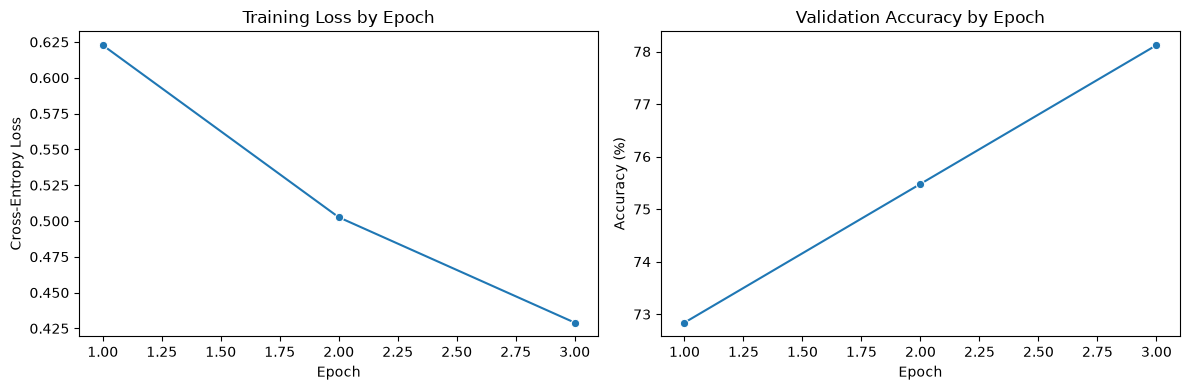


Saved results_summary.json


In [38]:
# Summarize results, visualize training, and save a machine-readable report.
best_epoch_result = max(
    training_history, key=lambda item: item["validation_accuracy"]
)

print("PROJECT RESULTS")
print("===============")
print(f"Training examples: {len(train_dataset):,}")
print(f"Validation examples: {len(val_dataset):,}")
print(f"Test examples: {len(test_dataset):,}")
print(f"Best epoch: {best_epoch_result['epoch']}")
print(f"Best validation accuracy: {best_epoch_result['validation_accuracy']:.2f}%")
print(f"Final test accuracy: {test_accuracy:.2f}%")
print(f"Total training time: {total_training_minutes:.1f} minutes on {device}")

print("\nKEY TAKEAWAYS")
print("1. The dataset is exactly balanced between positive and negative reviews, "
      "so accuracy is an interpretable metric and a 50% untrained baseline is expected.")
print("2. Subword tokenization and mask-aware mean pooling allow the transformer "
      "to convert variable-length reviews into fixed-size representations for classification.")
print("3. Selecting the checkpoint with the best validation accuracy protects the "
      "held-out test set from being used for model selection.")

history_df = pd.DataFrame(training_history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=history_df, x="epoch", y="training_loss", marker="o", ax=axes[0])
axes[0].set_title("Training Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
sns.lineplot(
    data=history_df, x="epoch", y="validation_accuracy", marker="o", ax=axes[1]
)
axes[1].set_title("Validation Accuracy by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

results_summary = {
    "training_examples": len(train_dataset),
    "validation_examples": len(val_dataset),
    "test_examples": len(test_dataset),
    "best_epoch": best_epoch_result["epoch"],
    "best_validation_accuracy": best_epoch_result["validation_accuracy"],
    "test_accuracy": test_accuracy,
    "training_minutes": total_training_minutes,
    "device": str(device),
    "checkpoint": CHECKPOINT_PATH.name,
    "training_history": training_history,
}

with Path("results_summary.json").open("w", encoding="utf-8") as file:
    json.dump(results_summary, file, indent=2)

print("\nSaved results_summary.json")


## Reusable Batch Inference Interface

The class below satisfies the optional standout criterion by loading the saved
checkpoint and predicting sentiment for a batch of raw review strings.

In [39]:
class SentimentPredictor:
    LABELS = {0: "negative", 1: "positive"}

    def __init__(self, checkpoint_path, device=None):
        checkpoint = torch.load(
            checkpoint_path, map_location="cpu", weights_only=False
        )
        self.config = checkpoint["config"]
        self.tokenizer = AutoTokenizer.from_pretrained(
            checkpoint["tokenizer_name"], use_fast=True
        )

        if device is None:
            if torch.cuda.is_available():
                device = torch.device("cuda")
            elif torch.backends.mps.is_available():
                device = torch.device("mps")
            else:
                device = torch.device("cpu")

        self.device = torch.device(device)
        self.model = DemoGPT(self.config)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.model.to(self.device)
        self.model.eval()
        self.test_accuracy = checkpoint.get("test_accuracy")

    def predict(self, texts):
        encoded = self.tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=self.config["context_size"],
            return_tensors="pt",
        )
        input_ids = encoded["input_ids"].to(self.device)

        with torch.no_grad():
            probabilities = torch.softmax(self.model(input_ids), dim=1)
            predicted_ids = probabilities.argmax(dim=1)

        results = []
        for text, class_id, scores in zip(
            texts, predicted_ids.cpu().tolist(), probabilities.cpu().tolist()
        ):
            results.append({
                "text": text,
                "label": self.LABELS[class_id],
                "confidence": scores[class_id],
            })
        return results


predictor = SentimentPredictor(CHECKPOINT_PATH)
demo_predictions = predictor.predict([
    "An amazing masterpiece with brilliant acting, a wonderful story, and a perfect ending. I absolutely loved it.",
    "The plot was tedious, predictable, and far too long.",
])
display(pd.DataFrame(demo_predictions)[["label", "confidence", "text"]])

,label,confidence,text
0,positive,0.999344,"An amazing masterpiece with brilliant acting, ..."
1,negative,0.998210,"The plot was tedious, predictable, and far too..."


## Submission Artifacts

- `SentimentScope_starter.ipynb` — completed notebook with saved outputs
- `sentimentscope_model.pt` — checkpoint that achieved the reported test accuracy
- `results_summary.json` — final metrics and training history
- `requirements.txt` — pinned environment dependencies
- `README.md` — project overview, reproduction steps, and artifact inventory